# Part 2: Operation of a Tidal Range Power Plant [55 pts]

One-way ebb-generation lagoon, 0-D model from Appendix 2, driven by [`Tidal_range_Dataset_2026.csv`](../Tidal_range_Dataset_2026.csv) — one 14-day spring-neap cycle.

In [1]:
import sys
from pathlib import Path
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from tidaltools import basin_model

figures_dir = Path("../figures")
figures_dir.mkdir(exist_ok=True)

DATA_FILE = "../Tidal_range_Dataset_2026.csv"

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "axes.grid": True, "grid.alpha": 0.3})

C_SEA, C_BASIN, C_HEAD, C_REF = "#8a8984", "#2a78d6", "#eb6834", "#8a8984"
C_HYD, C_EL = "#2a78d6", "#eb6834"
C_TXT = "#52514e"

## Input data

In [2]:
RHO = 1025.0        # kg/m3
G = 9.81            # m/s2

N_TURB = 10
P_UNIT_RATED = 20e6          # W (electrical, per turbine)
P_INSTALLED = N_TURB * P_UNIT_RATED
D_TURB = 8.0                 # m
ETA_T = 0.90
Q_TURB = 500.0               # m3/s per turbine
A_SLUICE = 500.0             # m2
CD = 1.0
H_SE = 3.0                   # m, start generating
H_EE = 1.0                   # m, end generating
A_NOMINAL = 10e6             # m2, "basin area of about 10 km2"
YEAR_FACTOR = 24.377         # 14-day cycles per year (given)

A_TURB_OPEN = N_TURB * np.pi * D_TURB**2 / 4    # turbine passage area
A_FILL = A_SLUICE + A_TURB_OPEN                 # sluices AND turbines open while filling

print(f"Turbine opening area (10 x pi D^2/4) : {A_TURB_OPEN:.1f} m2")
print(f"Total filling area A_s               : {A_FILL:.1f} m2")
print(f"Basin area A(-5), A(0), A(+5)        : "
      f"{basin_model.basin_area(-5) / 1e6:.2f}, {basin_model.basin_area(0) / 1e6:.2f}, {basin_model.basin_area(5) / 1e6:.2f} km2")

Turbine opening area (10 x pi D^2/4) : 502.7 m2
Total filling area A_s               : 1002.7 m2
Basin area A(-5), A(0), A(+5)        : 7.04, 11.00, 11.63 km2


### Tidal elevation data

In [3]:
df = pd.read_csv(DATA_FILE, encoding="utf-8-sig")
t_h = df["Total hour"].to_numpy()               # h
Y = df["Tidal range Y(t) (m)"].to_numpy()       # m about MSL
DT_H = t_h[1] - t_h[0]                          # h
DT_S = DT_H * 3600                                # s

print(f"{len(Y)} samples, dt = {DT_H:.1f} h, t = {t_h[0]} ... {t_h[-1]} h ({t_h[-1] / 24:.0f} days)")
print(f"Y min / max / mean = {Y.min():.2f} / {Y.max():.2f} / {Y.mean():.3f} m")

3360 samples, dt = 0.1 h, t = 0.1 ... 336.0 h (14 days)
Y min / max / mean = -4.99 / 4.99 / 0.007 m


## Energy potential, spring and neap tide [10 pts]

$E_{tide} = \rho g A R^2 / 2$ with the nominal 10 km² area, and as a check with the variable basin area $A(Z)$.

In [4]:
ranges = basin_model.ebb_ranges(t_h, Y)   # columns: t_hw, hw, lw, range
k_s, k_n = np.argmax(ranges[:, 3]), np.argmin(ranges[:, 3])
R_s, R_n = ranges[k_s, 3], ranges[k_n, 3]
TAU = 12.42 * 3600  # s

rows = []
for name, k in (("Spring", k_s), ("Neap", k_n)):
    t_hw, z_hi, z_lo, R = ranges[k]
    E_c = basin_model.tidal_energy_potential(R, A_NOMINAL)
    E_v = basin_model.tidal_energy_potential_variable_area(z_lo, z_hi, basin_model.basin_area)
    rows.append([name, t_hw, z_hi, z_lo, R, E_c / 3.6e12, E_c / TAU / 1e6, E_v / 3.6e12])

pot = pd.DataFrame(rows, columns=["Tide", "HW time [h]", "HW [m]", "LW [m]", "Range R [m]",
                                  "E_tide (A=10 km2) [GWh]", "Mean power per cycle [MW]",
                                  "E_tide (A(Z)) [GWh]"])
pot.round(3)

,Tide,HW time [h],HW [m],LW [m],Range R [m],E_tide (A=10 km2) [GWh],Mean power per cycle [MW],E_tide (A(Z)) [GWh]
0,Spring,12.3,4.975,-4.943,9.918,1.374,110.616,1.553
1,Neap,173.8,2.005,-2.004,4.008,0.224,18.066,0.253


In [5]:
E_s = basin_model.tidal_energy_potential(R_s, A_NOMINAL)
E_n = basin_model.tidal_energy_potential(R_n, A_NOMINAL)
print(f"Spring tide: R_s = {R_s:.2f} m -> E = {E_s / 1e12:.2f} TJ = {E_s / 3.6e9:.0f} MWh per tide, "
      f"mean power over the cycle {E_s / TAU / 1e6:.0f} MW")
print(f"Neap tide  : R_n = {R_n:.2f} m -> E = {E_n / 1e12:.2f} TJ = {E_n / 3.6e9:.0f} MWh per tide, "
      f"mean power over the cycle {E_n / TAU / 1e6:.0f} MW")
print(f"Spring / neap energy ratio = (R_s/R_n)^2 = {E_s / E_n:.1f}")

Spring tide: R_s = 9.92 m -> E = 4.95 TJ = 1374 MWh per tide, mean power over the cycle 111 MW
Neap tide  : R_n = 4.01 m -> E = 0.81 TJ = 224 MWh per tide, mean power over the cycle 18 MW
Spring / neap energy ratio = (R_s/R_n)^2 = 6.1


## 0-D model

$H = Z - Y$, updated with $Z_{i+1} = Z_i + \frac{Q_i}{A(Z_i)}\Delta t$. The modes cycle filling → holding → generating → holding, starting from $Z_0 = Y_0$.

In [6]:
sim = basin_model.simulate_one_way_ebb(
    t_h, Y, basin_model.basin_area,
    n_turb=N_TURB, q_turb=Q_TURB, eta_t=ETA_T, a_fill=A_FILL,
    h_se=H_SE, h_ee=H_EE, cd=CD, rho=RHO, g=G,
)
Z, H, Q, Q_sl, Q_tb, P_hyd, P_el, mode = (
    sim["Z"], sim["H"], sim["Q"], sim["Q_sl"], sim["Q_tb"], sim["P_hyd"], sim["P_el"], sim["mode"]
)
MODE_NAMES = basin_model.MODE_NAMES
FILL, HOLD_HW, GEN, HOLD_LW = basin_model.FILL, basin_model.HOLD_HW, basin_model.GEN, basin_model.HOLD_LW

print("Time share per mode over 14 days:")
for k, name in MODE_NAMES.items():
    print(f"  {name:<28}: {np.mean(mode == k) * 100:5.1f} %")
print(f"\nNumber of generating periods: {np.sum(np.diff((mode == GEN).astype(int)) == 1)}")
print(f"Max head during generation   : {H[mode == GEN].max():.2f} m")
print(f"Max power produced           : {P_el.max() / 1e6:.1f} MW")

Time share per mode over 14 days:
  Filling (sluicing)          :  39.7 %
  Holding (after HW)          :  21.0 %
  Generating (ebb)            :  29.3 %
  Holding (after generation)  :  10.0 %

Number of generating periods: 27
Max head during generation   : 5.06 m
Max power produced           : 229.2 MW


## Basin level and head over the 14-day cycle [10 pts]

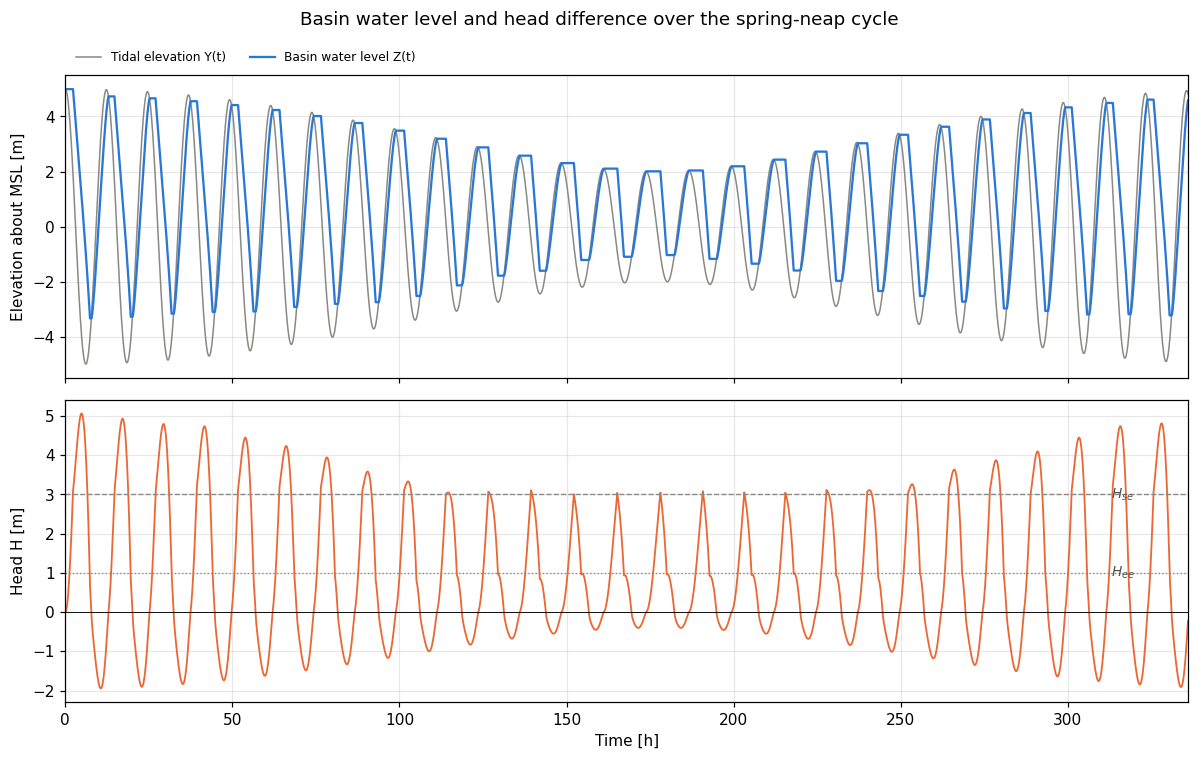

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.plot(t_h, Y, color=C_SEA, lw=1.0, label="Tidal elevation Y(t)")
ax1.plot(t_h, Z, color=C_BASIN, lw=1.5, label="Basin water level Z(t)")
ax1.set_ylabel("Elevation about MSL [m]")
fig.suptitle("Basin water level and head difference over the spring-neap cycle")
ax1.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncol=2, fontsize=8, frameon=False)

ax2.plot(t_h, H, color=C_HEAD, lw=1.2, label="Head difference H = Z - Y")
ax2.axhline(H_SE, color=C_REF, ls="--", lw=0.9)
ax2.axhline(H_EE, color=C_REF, ls=":", lw=0.9)
ax2.axhline(0, color="black", lw=0.6)
ax2.text(t_h[-1] - 23, H_SE, "$H_{se}$", va="center", fontsize=9, color=C_TXT)
ax2.text(t_h[-1] - 23, H_EE, "$H_{ee}$", va="center", fontsize=9, color=C_TXT)
ax2.set_xlabel("Time [h]")
ax2.set_ylabel("Head H [m]")
ax2.set_xlim(0, t_h[-1])

fig.tight_layout()
fig.savefig(figures_dir / "part3_range_levels_head_14days.png", dpi=300)
plt.show()

## Tidal elevation, basin level and operating modes, first 50 h [10 pts]

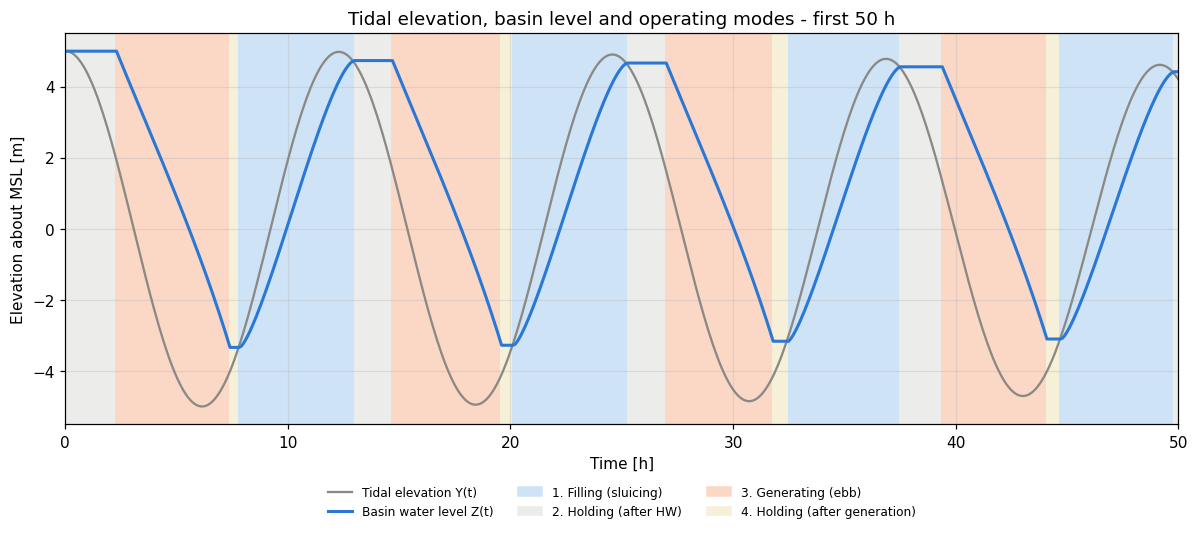

In [8]:
MODE_COLORS = {FILL: "#cfe3f7", HOLD_HW: "#ececea", GEN: "#fbd7c6", HOLD_LW: "#f6f0d8"}
T50 = 50.0
w = t_h <= T50


def shade_modes(ax):
    idx = np.where(w)[0]
    start = idx[0]
    for j in range(idx[0] + 1, idx[-1] + 2):
        if j > idx[-1] or mode[j] != mode[start]:
            ax.axvspan(t_h[start] - DT_H / 2, t_h[min(j, idx[-1])] - DT_H / 2 if j <= idx[-1] else T50,
                       color=MODE_COLORS[mode[start]], lw=0, zorder=0)
            start = j


mode_legend = [Patch(color=MODE_COLORS[k], label=f"{k}. {MODE_NAMES[k]}") for k in MODE_NAMES]

fig, ax = plt.subplots(figsize=(11, 5))
shade_modes(ax)
l1, = ax.plot(t_h[w], Y[w], color=C_SEA, lw=1.5, label="Tidal elevation Y(t)")
l2, = ax.plot(t_h[w], Z[w], color=C_BASIN, lw=2, label="Basin water level Z(t)")
ax.set_xlim(0, T50)
ax.set_xlabel("Time [h]")
ax.set_ylabel("Elevation about MSL [m]")
ax.set_title("Tidal elevation, basin level and operating modes - first 50 h")
ax.legend(handles=[l1, l2] + mode_legend, loc="upper center", bbox_to_anchor=(0.5, -0.13),
          ncol=3, fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(figures_dir / "part3_range_levels_modes_50h.png", dpi=300)
plt.show()

## Hydraulic power and power produced, first 50 h [10 pts]

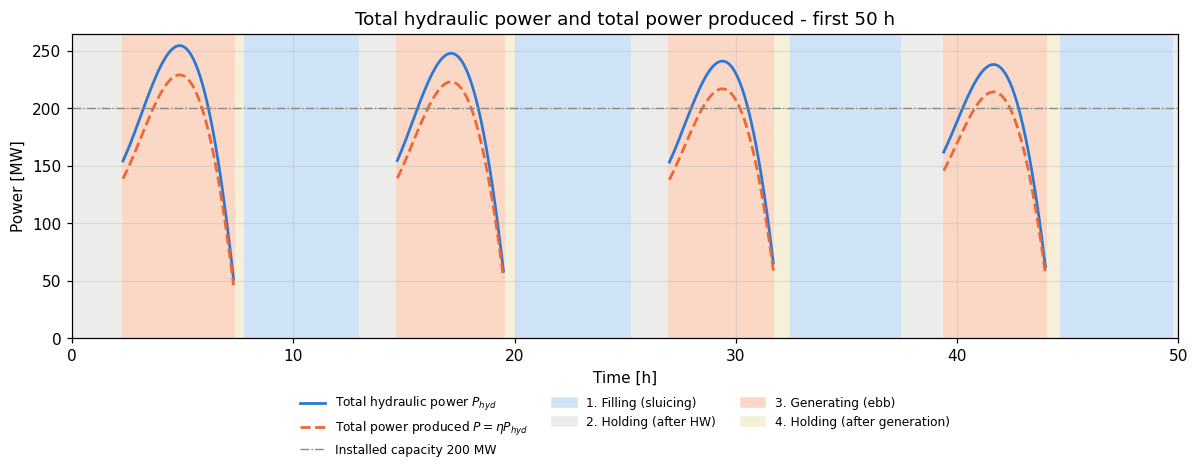

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
shade_modes(ax)
p_h = np.where(mode == GEN, P_hyd, np.nan)
p_e = np.where(mode == GEN, P_el, np.nan)
ax.plot(t_h[w], p_h[w] / 1e6, color=C_HYD, lw=1.8, label="Total hydraulic power $P_{hyd}$")
ax.plot(t_h[w], p_e[w] / 1e6, color=C_EL, lw=1.8, ls="--", label="Total power produced $P = \\eta P_{hyd}$")
ax.axhline(P_INSTALLED / 1e6, color="#8a8984", ls="-.", lw=0.9, label="Installed capacity 200 MW")
ax.set_xlim(0, T50)
ax.set_ylim(bottom=0)
ax.set_xlabel("Time [h]")
ax.set_ylabel("Power [MW]")
ax.set_title("Total hydraulic power and total power produced - first 50 h")
ax.legend(handles=ax.get_legend_handles_labels()[0] + mode_legend, loc="upper center",
          bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(figures_dir / "part3_range_power_50h.png", dpi=300)
plt.show()

## Flow rates, first 50 h [10 pts]

Positive flow is into the basin, negative out through the turbines.

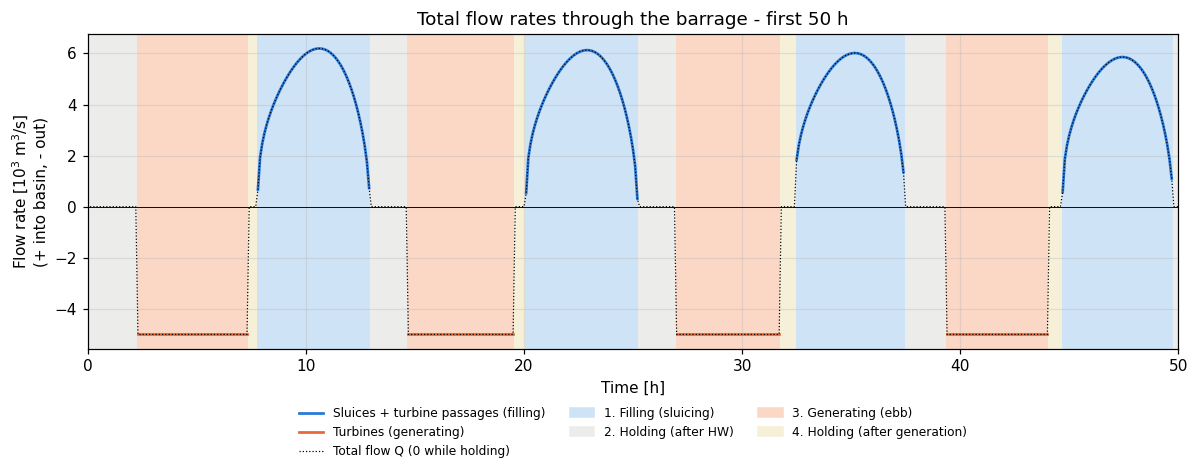

Peak filling flow  : 6195 m3/s
Turbine flow (gen) : 5000 m3/s


In [10]:
fig, ax = plt.subplots(figsize=(11, 4.5))
shade_modes(ax)
q_fill = np.where(mode == FILL, Q_sl, np.nan)
q_gen = np.where(mode == GEN, -Q_tb, np.nan)
ax.plot(t_h[w], q_fill[w] / 1e3, color=C_BASIN, lw=1.8, label="Sluices + turbine passages (filling)")
ax.plot(t_h[w], q_gen[w] / 1e3, color=C_EL, lw=1.8, label="Turbines (generating)")
ax.plot(t_h[w], Q[w] / 1e3, color="black", lw=0.8, ls=":", label="Total flow Q (0 while holding)")
ax.axhline(0, color="black", lw=0.6)
ax.set_xlim(0, T50)
ax.set_xlabel("Time [h]")
ax.set_ylabel("Flow rate [10$^3$ m$^3$/s]\n(+ into basin, - out)")
ax.set_title("Total flow rates through the barrage - first 50 h")
ax.legend(handles=ax.get_legend_handles_labels()[0] + mode_legend, loc="upper center",
          bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(figures_dir / "part3_range_flow_50h.png", dpi=300)
plt.show()

print(f"Peak filling flow  : {Q_sl.max():.0f} m3/s")
print(f"Turbine flow (gen) : {N_TURB * Q_TURB:.0f} m3/s")

## Annual energy yield and capacity factor [5 pts]

In [11]:
E_14d = P_el.sum() * DT_S          # J
AEY_R = basin_model.annual_energy_yield(P_el, DT_S, YEAR_FACTOR)   # J
CF_R = basin_model.capacity_factor(AEY_R, P_INSTALLED)

starts = np.where(np.diff((mode == GEN).astype(int)) == 1)[0] + 1
ends = np.where(np.diff((mode == GEN).astype(int)) == -1)[0] + 1
per_ebb = [P_el[s:e].sum() * DT_S / 3.6e9 for s, e in zip(starts, ends)]

print(f"Energy over the 14-day cycle : {E_14d / 3.6e12:.2f} GWh")
print(f"Energy per ebb (spring)      : {max(per_ebb):.0f} MWh   (potential {E_s / 3.6e9:.0f} MWh)")
print(f"Energy per ebb (neap)        : {min(per_ebb):.0f} MWh   (potential {E_n / 3.6e9:.0f} MWh)")
print(f"Mean power over the cycle    : {P_el.mean() / 1e6:.1f} MW")
print()
print(f"AEY = {YEAR_FACTOR} x E_14d      : {AEY_R / 3.6e12:.1f} GWh/yr")
print(f"Capacity factor              : {CF_R:.3f} = {CF_R * 100:.1f} %")

Energy over the 14-day cycle : 14.23 GWh
Energy per ebb (spring)      : 916 MWh   (potential 1374 MWh)
Energy per ebb (neap)        : 190 MWh   (potential 224 MWh)
Mean power over the cycle    : 42.4 MW

AEY = 24.377 x E_14d      : 346.9 GWh/yr
Capacity factor              : 0.198 = 19.8 %


### Sensitivity check: turbine rating

$Q_t$ and $\eta$ are fixed at all heads, so the model is not capped at the 20 MWe per-turbine rating. Repeated below with the output capped at 200 MW.

In [12]:
P_cap = np.minimum(P_el, P_INSTALLED)
AEY_cap = YEAR_FACTOR * P_cap.sum() * DT_S
CF_cap = basin_model.capacity_factor(AEY_cap, P_INSTALLED)
print(f"Time above 200 MW during generation : {np.mean(P_el[mode == GEN] > P_INSTALLED) * 100:.1f} % of generating time")
print(f"AEY (capped at 200 MW)               : {AEY_cap / 3.6e12:.1f} GWh/yr  ({(1 - AEY_cap / AEY_R) * 100:.1f} % lower)")
print(f"CF  (capped at 200 MW)               : {CF_cap * 100:.1f} %")

Time above 200 MW during generation : 12.2 % of generating time
AEY (capped at 200 MW)               : 343.4 GWh/yr  (1.0 % lower)
CF  (capped at 200 MW)               : 19.6 %
